допустим есть данные о клиентах: годовой доход и оценка затрат (насколько активно они тратят деньги).  

необходимо разделить клиентов на группы, чтобы понять кого нужно привлечь скидками, какие клиенты уже активны.  
1 группа - низкий доход, низкие траты.  
2 группа - высокий доход, средние траты.  
3 группа - высокий доход, активные траты.  

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)  # For reproducibility
income = np.random.normal(loc=50000, scale=15000, size=1000)  # Simulated income data
spending_score = np.random.normal(loc=50, scale=10, size=1000)  # Simulated spending score data

data = pd.DataFrame({
    'Income': income,
    'SpendingScore': spending_score
})

print(data.head())

         Income  SpendingScore
0  57450.712295      63.993554
1  47926.035482      59.246337
2  59715.328072      50.596304
3  72845.447846      43.530632
4  46487.699379      56.982233


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


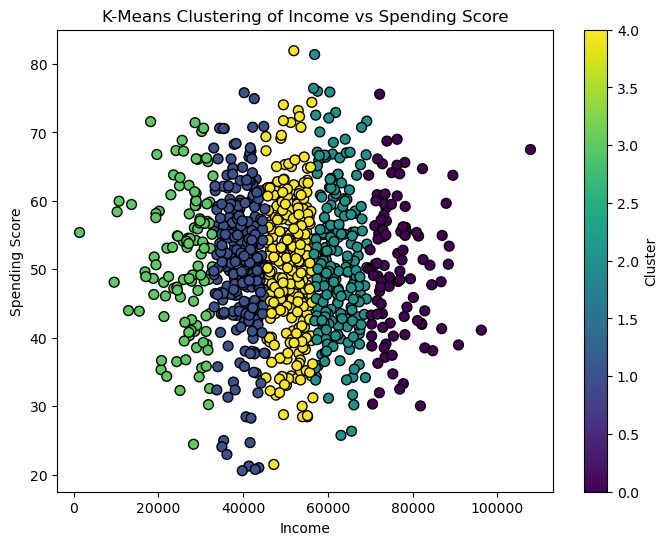

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = data[['Income', 'SpendingScore']]

kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(data['Income'], data['SpendingScore'], c=data['Cluster'], cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('K-Means Clustering of Income vs Spending Score')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.colorbar(label='Cluster')
plt.show()

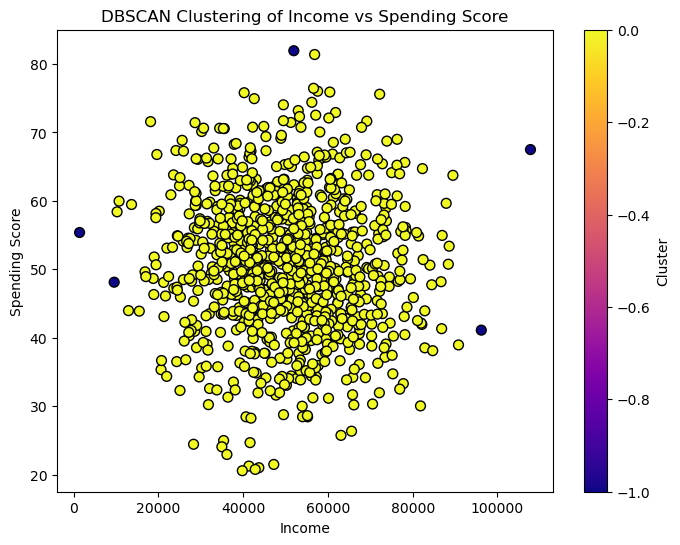

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# DBSCAN requires feature scaling (т.к. чувствителен к масштабу данных)
# StandardScaler is used to standardize features by removing the mean and scaling to unit variance
# т.е. нулевое среднее и единичная дисперсия (стандартное отклонение = 1)
# это нужно чтобы доходы, например в диапазоне десятков тысяч, не доминировали над оценками расходов, которые могут быть в диапазоне десятков или сотен
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# min_samples=5 - минимальное количество точек, которые должны находиться в радиусе eps, чтобы точка считалась "ядром" кластера
# метод fit_predict() обучает каждый объект и возвращает метку кластера для каждого объекта
dbscan = DBSCAN(eps=0.5, min_samples=5)
data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(data['Income'], data['SpendingScore'], c=data['DBSCAN_Cluster'], cmap='plasma', marker='o', edgecolor='k', s=50)
plt.title('DBSCAN Clustering of Income vs Spending Score')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.colorbar(label='Cluster')
plt.show()

чтобы лучше понять многомерные данные, добавим доп. характеристики

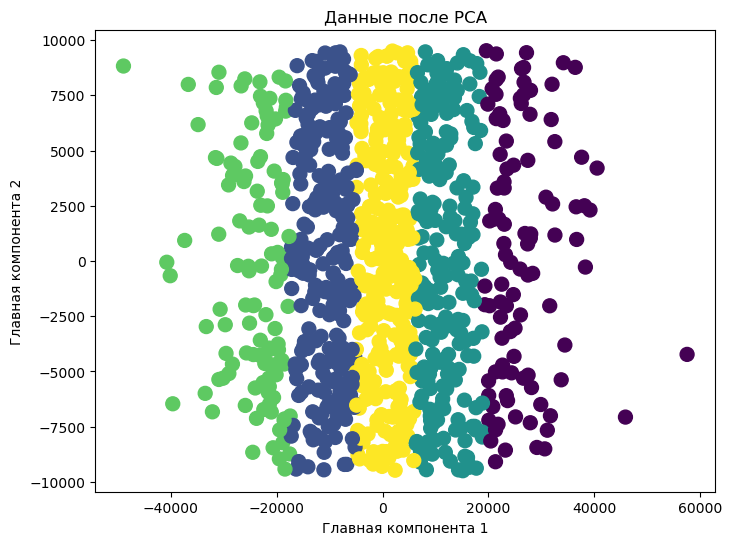

In [11]:
from sklearn.decomposition import PCA

# PCA уменьшает размерность данных, преобразуя их в новые переменные - главные компоненты
# главные компоненты представляют собой линейные комбинации исходных признаков,
# но они упорядочены таким образом что первая главная компонента объясняет наибольшую часть разброса данных,
# вторая - чуть меньше и т.д.

data['Age'] = np.random.randint(18, 70, size=1000)  # Simulated age data
data['Savings'] = np.random.normal(loc=10000, scale=5000, size=1000)  # Simulated savings data
data['Debt'] = np.random.randint(1000, 20000, 1000)

X_multidimensional = data[['Income', 'SpendingScore', 'Age', 'Savings', 'Debt']]

pca = PCA(n_components=2) # уменьшить до двух гл.компонент

# метод fit_transform() обучает PCA и преобразует исходные данные в проекцию на две главные компоненты 
# результат X_pca содержит те же объекты, но теперь каждая строка описана двумя числами (значениями главных компонент)
X_pca = pca.fit_transform(X_multidimensional)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['Cluster'], cmap='viridis', s=100)
plt.title('Данные после PCA')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.show()